In [1]:
# --- Standard library & numerics ---
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

# --- JAX ---
import jax
import jax.numpy as jnp

# Use 64-bit everywhere; JAX defaults to 32-bit which is too imprecise for FEM.
jax.config.update("jax_enable_x64", True)

# --- coilforce ---
from coilforce.curve_jax   import CurveXYZFourierJAX
from coilforce.coil_fem    import CoilFEM
from coilforce.fem_objectives import (
    soft_max_von_mises,
    mean_von_mises_volume_weighted,
    von_mises_on_quadrature,
)
from coilforce.symmetries  import n_coils_total

# JAX-FEM Landreman-Hurwitz cross-section regularisation helper
from simsopt.field.selffield import regularization_rect

print("JAX devices:", jax.devices())
print("JAX x64 enabled:", jax.config.jax_enable_x64)

# Disable JAX-FEM solver log
import logging
logging.getLogger('jax_fem').setLevel(logging.WARNING)

[06-15 17:00:52][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

JAX devices: [CpuDevice(id=0)]
JAX x64 enabled: True


In [2]:
# Loading config from simsopt
from simsopt.configs import get_data
from simsopt.geo import plot
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=20, points_per_period=2)
# list of CurveXYZFourierJAX, one per *base* coil (before symmetry expansion)
base_curves_jax = [CurveXYZFourierJAX.from_simsopt(c) for c in curves[:5]]
base_curves = curves[:5]
# 1-D JAX array of currents [A], shape (n_base,)
base_currents_jax = jnp.array([c.current for c in currents[:5]])
base_currents = currents[:5]
stellsym = True

In [12]:
# Rectangular 100 mm × 50 mm cross-section (half-widths in metres).
# A single dict is broadcast to all base coils automatically.
mesh_options = dict(
    shape        = 'rect',
    w1           = 0.2,   # 0.20 m half-width
    w2           = 0.2,   # 0.20 m half-width
    frame        = 'rmf',
    aspect_ratio = 1.0,   # aim for cubic elements
    mesh_type    = 'TET10',
)

# Winkler BC and linear-solver settings.
problem_options = dict(
    winkler_k      = 1e10,      # Winkler spring stiffness [N/m³]
    solver         = 'umfpack', # A CPU sparse solver. Future version 
    adjoint_solver = 'umfpack', # will support cuSparse GPU sparse solvers.
)

# Material settings
material_options_const_temp = dict(
    E       = 200e9,   # Young's modulus [Pa]
    nu      = 0.30,    # Poisson ratio
    density = 7800.0,  # mass density [kg m⁻³]
)

material_options_variable_temp = dict(
    alpha             = 16.5e-6,  # CTE for 316 LN stainless steel [1/K]
    init_temperature  = 293.15,   # stress-free reference temperature [K]
    final_temperature = 4.0,      # superconducting service temperature [K]
) | material_options_const_temp

In [30]:
from jax.nn import sigmoid

# Set the size of the support clamp (in other words, the region
# with non-zero Winkler spring coefficients).
# Clamp radius = 2 × coil half-width; sigmoid sharpness tuned to clamp_radius.
clamp_radius = 2 * max(mesh_options['w1'], mesh_options['w2'])
# The "steepness" of the sigmoid function at the edge of the clamp.
sigmoid_beta  = 20.0 / clamp_radius

clamp_num = 4

init_phi = jnp.linspace(0, 1, clamp_num, endpoint=False)

support_dofs = [{'phis': init_phi}]* 5

# Support function that represent clamps
# with variable locations
def support_fn(
    surface_points: jax.Array,   # (n_surface_nodes, 3)  traced
    curve_jax: 'CurveXYZFourierJAX',  # current coil geometry
    dofs: dict | None,           # optimisable support params (or None)
):
    phis = dofs['phis']
    gamma_support = curve_jax.gamma_eval(phis) # (n_support, 3)
    # Safe norm
    distances = jnp.sqrt(jnp.sum(
        (surface_points[:, None, :] - gamma_support[None, :, :])**2,
        axis=-1
    ) + 1e-10) # (n_surface_nodes, n_support)
    w = sigmoid(sigmoid_beta * (clamp_radius - distances))
    return jnp.max(w, axis=-1)   # union of the two spheres

In [31]:
init_phi

Array([0.  , 0.25, 0.5 , 0.75], dtype=float64)

In [32]:
# Initial DOF vectors; list of (n_dofs_i,) JAX arrays, one per base coil.
dof_sizes = [int(c.dofs.shape[0]) for c in base_curves_jax]
init_dofs = [c.dofs for c in base_curves_jax]
init_currents = base_currents_jax

print("DOF sizes per coil:", dof_sizes)

fem = CoilFEM(
    base_curves_jax     = base_curves_jax,
    base_currents_jax   = base_currents_jax,
    nfp              = nfp,
    stellsym         = stellsym,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    base_support_fns = support_fn,
    base_support_dofs = support_dofs,
    problem_options  = problem_options,
)

DOF sizes per coil: [123, 123, 123, 123, 123]


Base coils : 5
Total coils: 50  (nfp=5, stellsym=True)
Quad points: 40 per coil
Orders: 20
DOFs/coil  : 123


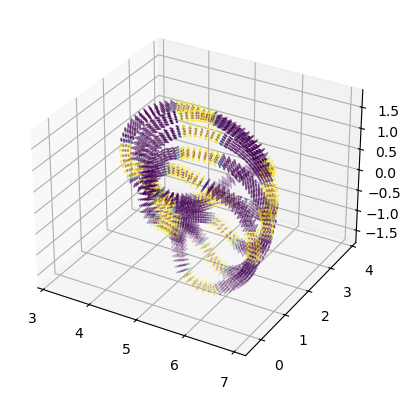

In [33]:
self = fem
import numpy as onp
from coilforce.coil_fem    import _validate_support_dofs

# ----- quick sanity checks ---------------------------------------------------
n_base = len(base_curves_jax)
n_total = n_coils_total(n_base, nfp, stellsym)
n_quad  = base_curves_jax[0].quadpoints.shape[0]
n_order  = base_curves_jax[0].order
print(f"Base coils : {n_base}")
print(f"Total coils: {n_total}  (nfp={nfp}, stellsym={stellsym})")
print(f"Quad points: {n_quad} per coil")
print(f"Orders: {n_order}")
print(f"DOFs/coil  : {base_curves_jax[0].dofs.shape[0]}")

base_curves_dofs = init_dofs

winkler_k = float(self.problem_options['winkler_k'])
sd = _validate_support_dofs(support_dofs, n_base)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
for i, coil_mesh in enumerate(self.meshes):
    pts_i  = self._mesh_points_from_dofs(base_curves_dofs[i], i)
    pts_np = onp.asarray(pts_i, dtype=onp.float64)
    n_nodes = pts_np.shape[0]
    surf_idx = onp.asarray(self._surface_node_indices[i], dtype=onp.int32)
    weights_surf = onp.asarray(
        self._compute_support_weights(i, pts_i, base_curves_dofs[i], sd[i]),
        dtype=onp.float64,
    )
    weight_full = onp.zeros(n_nodes, dtype=onp.float64)
    weight_full[surf_idx] = weights_surf
    ax.scatter(
        pts_np[:, 0], 
        pts_np[:, 1], 
        pts_np[:, 2],
        s=0.1,
        c=weight_full
    )